# K-Means Clustering

### Random 하게 생성된 toy dataset 으로 K-Means clustering test

make_blobs : 
```
    Input :
         n_samples :  cluster 에 균등 분할될 total data point 숫자  
         centers : generate 할 centroid 숫자  
         cluster_std : cluster 의 standard deviation    

    Output : 
        X: 생성된 sample 들  
        y: 각 sample 의 label
```
KMeans :  
> init : initialization method -> k-means++ (smart choosing of centroids)  
> n_clusters : k 값  
> n_init : 반복횟수  

필요한 라이브러리를 import 합니다. K-Means 클러스터링과 데이터 생성, 시각화를 위한 도구들을 사용합니다.

In [18]:
# 필요한 라이브러리 import
import random  # 랜덤 함수
import numpy as np  # 수치 연산
import matplotlib.pyplot as plt  # 그래프 시각화
from sklearn.cluster import KMeans  # K-Means 클러스터링 알고리즘
from sklearn.datasets import make_blobs  # 샘플 데이터 생성
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["PYTHONIOENCODING"] = "utf-8"

재현 가능한 결과를 얻기 위해 랜덤 시드를 설정합니다. 같은 시드를 사용하면 동일한 데이터가 생성됩니다.

In [19]:
# 재현 가능한 결과를 위한 랜덤 시드 설정
np.random.seed(101)

클러스터 중심 좌표를 정의합니다. 3개의 중심점을 지정하여 데이터를 생성할 위치를 결정합니다.

In [20]:
# 클러스터 중심 좌표를 리스트로 정의 (총 3개의 중심)
# 각 중심점은 [x좌표, y좌표] 형태
centroidLocation = [[3, 2], [1, -1], [-1, 2]]

make_blobs를 사용하여 지정한 중심 좌표를 기준으로 샘플 데이터를 생성합니다. 총 1500개의 데이터 포인트가 3개의 클러스터로 나뉘어 생성됩니다.

In [21]:
# 지정한 중심 좌표를 기준으로 총 1500개의 샘플 데이터를 생성
# n_samples=1500: 생성할 샘플의 총 개수
# centers=centroidLocation: 클러스터 중심 좌표 지정
# X: 생성된 데이터 포인트 (2차원 배열)
# _: 클러스터 라벨 (여기서는 사용하지 않으므로 _로 처리)
X, _ = make_blobs(n_samples=1500, centers=centroidLocation)

생성된 데이터 포인트를 산점도로 시각화합니다. 데이터의 분포를 확인할 수 있습니다.

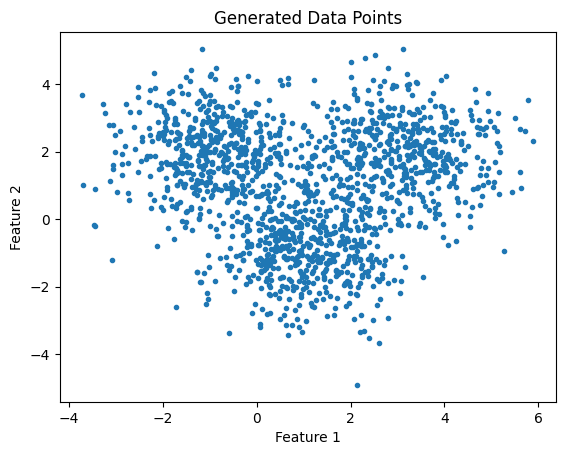

In [22]:
# 생성된 데이터 포인트를 산점도로 시각화
# X[:,0]: 첫 번째 특성(x좌표), X[:,1]: 두 번째 특성(y좌표)
# marker='.': 작은 점으로 표시
plt.scatter(X[:,0], X[:,1], marker='.')
plt.xlabel('Feature 1')  # x축 레이블
plt.ylabel('Feature 2')  # y축 레이블
plt.title('Generated Data Points')  # 그래프 제목
plt.show()  # 그래프 출력

데이터의 형태와 일부 샘플을 확인합니다. 데이터의 크기와 구조를 파악할 수 있습니다.

In [25]:
# 데이터의 형태 확인
print("Data shape:", X.shape)  # (샘플 수, 특성 수)
# 처음 5개 샘플 확인
print(X[:5])

Data shape: (1500, 2)
[[-1.21729731  0.34549836]
 [-1.21658421 -1.87049396]
 [ 4.14277516  2.67891613]
 [ 1.2492407   0.54037484]
 [ 4.09955027  0.97450081]]


클러스터 개수(K 값)를 설정합니다. 생성된 데이터가 3개의 중심을 가지고 있으므로 K=3으로 설정합니다.

In [26]:
# 클러스터 개수 설정 (K 값)
nclusters = 3

K-Means 클러스터링 모델을 생성합니다. n_clusters로 클러스터 개수를 지정하고, 기본값으로 k-means++ 초기화 방법을 사용합니다.

In [27]:
# K-Means 클러스터링 모델 생성
# n_clusters=nclusters: 클러스터 개수 (K 값)
k_means = KMeans(n_clusters=nclusters)

K-Means 알고리즘으로 데이터를 학습시킵니다. 각 데이터 포인트를 가장 가까운 클러스터 중심에 할당하고, 중심점을 반복적으로 업데이트합니다.

In [28]:
# K-Means 알고리즘으로 데이터 학습
# 각 데이터 포인트를 가장 가까운 클러스터 중심에 할당
k_means.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


각 데이터 포인트가 속한 클러스터 레이블을 확인합니다. 0, 1, 2 중 하나의 값으로 각 샘플이 어느 클러스터에 속하는지 나타냅니다.

In [29]:
# 각 데이터 포인트가 속한 클러스터 레이블 확인
# 0, 1, 2 중 하나의 값으로 각 샘플이 어느 클러스터에 속하는지 나타냄
k_means.labels_

array([2, 0, 1, ..., 0, 2, 2], shape=(1500,), dtype=int32)

학습된 클러스터 중심 좌표를 확인합니다. 알고리즘이 찾은 각 클러스터의 중심점 위치를 확인할 수 있습니다.

In [30]:
# 학습된 클러스터 중심 좌표 확인
# cluster_centers_: 각 클러스터의 중심점 좌표
centers = k_means.cluster_centers_
# 클러스터 중심 좌표 출력
centers

array([[ 1.05328721, -0.96170352],
       [ 3.14738308,  2.02818883],
       [-0.97958037,  2.04290344]])

시각화를 위한 색상 맵을 생성합니다. 클러스터 중심점은 진한 색상으로, 데이터 포인트는 연한 색상으로 표시하여 구분하기 쉽게 합니다.

In [32]:
from matplotlib.colors import ListedColormap

# 클러스터 중심점 표시용 (진한 색상)
colors_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# 데이터 포인트 표시용 (연한 색상)
# 연한 빨간색(#FFAAAA), 연한 초록색(#AAFFAA), 연한 파란색(#AAAAFF)
colors_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

클러스터링 결과를 시각화합니다. 각 클러스터의 데이터 포인트와 중심점을 다른 색상으로 표시하여 클러스터링 결과를 확인할 수 있습니다.

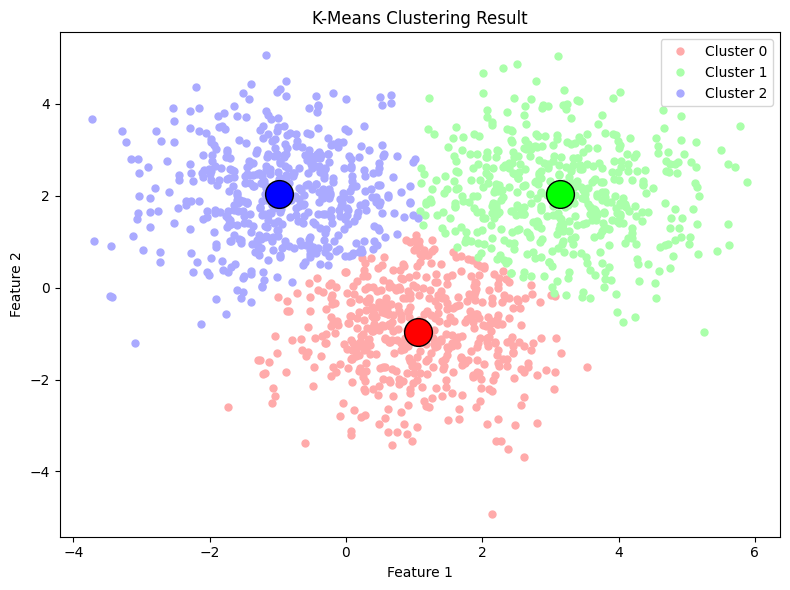

In [33]:
plt.figure(figsize=(8,6))

# 클러스터의 수만큼 반복하여 각 클러스터의 데이터 포인트와 중심을 플로팅
for i in range(nclusters):
    # i번째 클러스터에 속하는 데이터 포인트를 선택
    members = k_means.labels_ == i
    
    # X[members, 0]: i번째 클러스터의 첫 번째 특성
    # X[members, 1]: i번째 클러스터의 두 번째 특성
    # marker='.': 작은 점으로 표시
    # color=colors_light(i): 연한 색상 사용
    # markersize=10: 점의 크기
    plt.plot(X[members, 0], X[members, 1], '.', 
             color=colors_light(i), markersize=10, label='Cluster {}'.format(i))
    
    # i번째 클러스터의 중심을 플로팅
    # marker='o': 원형 마커
    # color=colors_bold(i): 진한 색상 사용
    # markeredgecolor='k': 검은색 테두리
    # markersize=20: 중심점의 크기
    plt.plot(centers[i, 0], centers[i, 1], 'o', 
             color=colors_bold(i), markeredgecolor='k', markersize=20)

# 그래프의 제목 설정
plt.title("K-Means Clustering Result")
# x축 레이블
plt.xlabel('Feature 1')
# y축 레이블
plt.ylabel('Feature 2')
# 범례 표시
plt.legend()
# 레이아웃 정리
plt.tight_layout()
# 그래프 표시
plt.show()